In [ ]:
# Importaciones
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import pandas as pd

In [ ]:
# Importaciones ML
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# Lectura de datos.
def read_data(path):
    """Lee un archivo CSV y devuelve un DataFrame de Pandas."""
    df = pd.read_csv(path)
    return df

In [ ]:
df = read_data("C:\Desarrollo\ai-projects\datasets\Student_Performance.csv")
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [13]:
# Transformar data -> Acá Extracurricular Activities es un dato con un orden establecido.
df['Extracurricular Activities'] = df['Extracurricular Activities'].astype('category')
df['Extracurricular Activities'] = df['Extracurricular Activities'].cat.codes
df


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [15]:
# Aseguramos que no hayan datos nulos.
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [16]:
# Asignamos los valores de X.
X = df.drop(columns='Performance Index')
X

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [17]:
y = df['Performance Index']
y

,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0
...,...
9995,23.0
9996,58.0
9997,74.0
9998,95.0


In [18]:
# Separación de conjunto de datos
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [19]:
# Predicción.
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [20]:
# Parámetro theta (b)
lr.intercept_

np.float64(-33.836543807141744)

In [23]:
# Parámetros Theta 1
lr.coef_

array([2.85895223, 1.01551979, 0.58171285, 0.47967676, 0.19039416])

In [24]:
# Predicción.
y_pred_train = lr.predict(x_train)

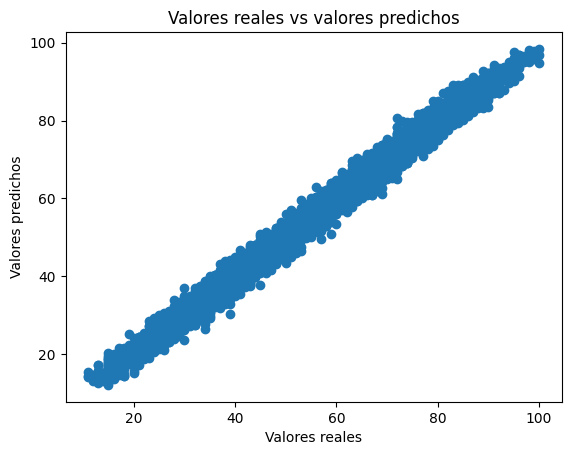

In [26]:
plt.scatter(y_train, y_pred_train)
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('Valores reales vs valores predichos')
plt.show()

In [27]:
# Error y coeficiente R2
mse = mean_squared_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)
print('Error cuadrático medio:', mse)
print('Coeficiente de determinación:', r2)
#

Error cuadrático medio: 4.193473712437295
Coeficiente de determinación: 0.9886221887978632


In [28]:
# Predicción con los valores de prueba
y_pred_test = lr.predict(x_test)

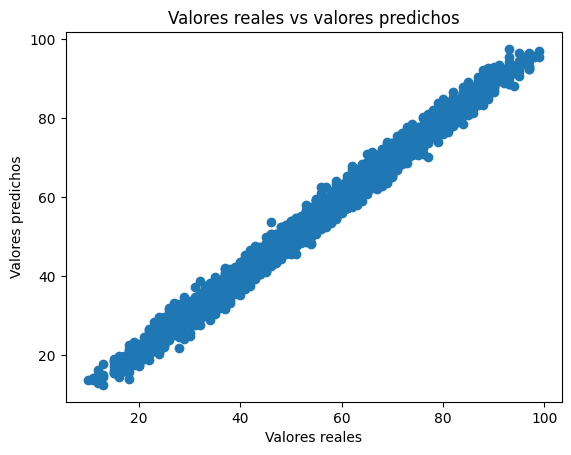

In [29]:
plt.scatter(y_test, y_pred_test)
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('Valores reales vs valores predichos')
plt.show()

In [30]:
# Error y coeficiente R2
mse = mean_squared_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)
print('Error cuadrático medio:', mse)
print('Coeficiente de determinación:', r2)

Error cuadrático medio: 4.193473712437295
Coeficiente de determinación: 0.9886221887978632


In [31]:
new_example = pd.DataFrame({
    'Hours Studied': [8],
    'Previous Scores': [85],
    'Extracurricular Activities': [1], # 0 for No, 1 for Yes
    'Sleep Hours': [7],
    'Sample Question Papers Practiced': [4]
})

predicted_performance = lr.predict(new_example)

print(f"El índice de rendimiento predicho para el nuevo ejemplo es: {predicted_performance[0]:.2f}")

El índice de rendimiento predicho para el nuevo ejemplo es: 80.06
